### Visualization

In [2]:
### import libraries
import pandas as pd
import matplotlib .pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings(action="ignore")

In [3]:
agric_df  = pd.read_csv("agriculture.csv")
crop_df = pd.read_csv("crops.csv")


### Simple Line Chart

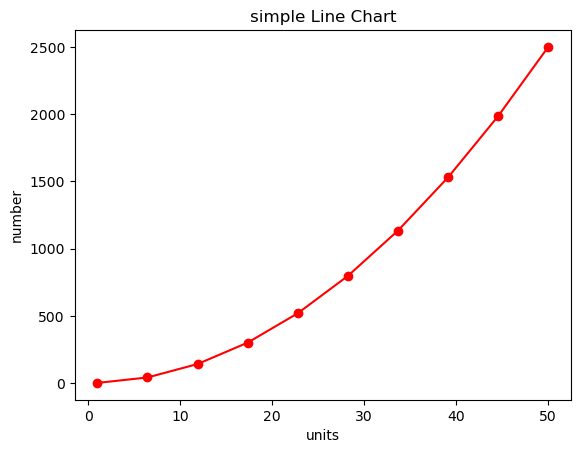

In [4]:
x = np.linspace(1,50,10)
y=x**2
plt.plot(x,y,color="red",marker="o")
plt.title("simple Line Chart")
plt.xlabel("units")
plt.ylabel("number")
plt.show()

In [5]:
agric_df.head()

,RecordID,FarmID,FarmName,Region,CropType,Year,Month,Rainfall_mm,Soil_pH,Soil_Nitrogen,Soil_Phosphorus,Yield_Tonnes
0,1,1,Faith Crops,Western,Cassava,2022,5,274.29,5.30,35.67,21.68,9.65
1,2,1,New Hope Crops,Northern,Maize,2021,6,150.00,5.55,28.69,28.37,3.93
2,3,1,Victory Estate,Ashanti,Cassava,2021,7,229.41,5.14,42.34,15.97,11.14
3,4,1,Highland Plantation,Volta,Maize,2019,9,101.60,7.05,34.81,14.27,4.45
4,5,1,Green Valley Farm,Western,Maize,2021,2,113.07,6.28,24.36,29.87,2.02


In [6]:
agric_df.dtypes

RecordID             int64
FarmID               int64
FarmName            object
Region              object
CropType            object
Year                 int64
Month                int64
Rainfall_mm        float64
Soil_pH            float64
Soil_Nitrogen      float64
Soil_Phosphorus    float64
Yield_Tonnes       float64
dtype: object

In [7]:
### we want to know the average yield per year
avg_yield = agric_df.groupby("Year")["Yield_Tonnes"].mean()

In [8]:
avg_yield.index

Index([2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype='int64', name='Year')

In [9]:
avg_yield.values

array([ 9.39348659, 11.85649254, 11.29455645, 10.98546429, 10.13917603,
       10.70534783,  9.99719512])

### Traditional method

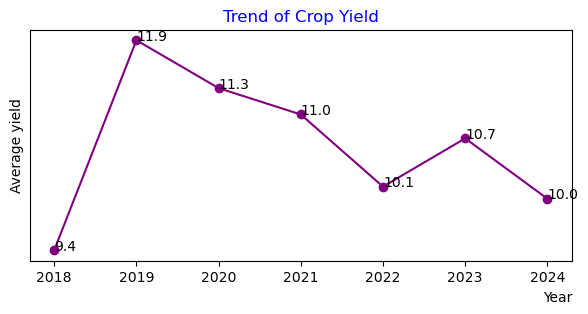

<Figure size 640x480 with 0 Axes>

In [10]:
### Traditional method
plt.figure(figsize =(7,3))
plt.plot(avg_yield.index, avg_yield.values ,color = 'purple', marker = 'o')
plt.title('Trend of Crop Yield' , color = 'blue')
plt.xlabel('Year', loc = 'right')
for x,y in zip(avg_yield.index , avg_yield.values):
    plt.text(x,y, f'{y:.1f}' , color ='black')
plt.ylabel('Average yield')
plt.yticks([]) ## this is to remove the y axis
plt.show()
### save the figure
plt.savefig("yield.png")

### OOP Method

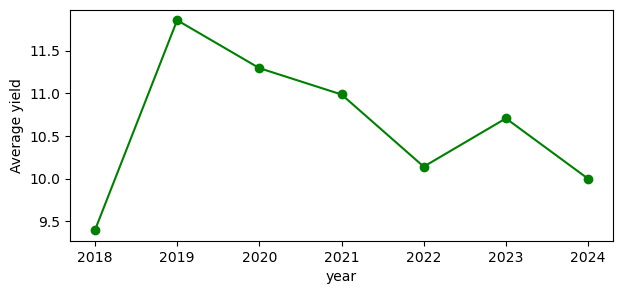

In [11]:

figure,axes = plt.subplots(figsize=(7,3))
axes.plot(avg_yield.index,avg_yield.values,marker="o",color="green")
axes.set_xlabel("year")
axes.set_ylabel("Average yield")
plt.show()
figure.savefig("oop.png") ### save the figure  

### using pandas

In [12]:
avg_yield= agric_df.groupby("Year")["Yield_Tonnes"].mean()

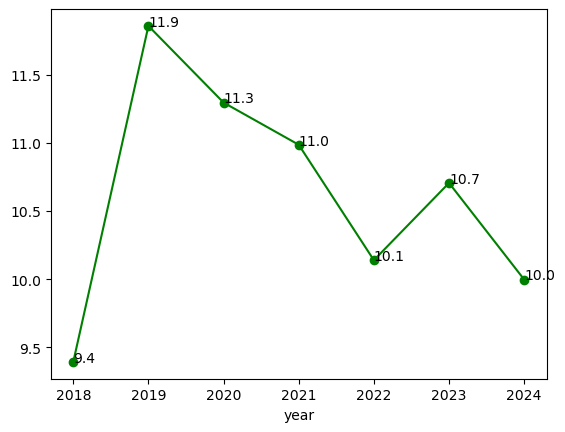

In [13]:
ax = avg_yield.plot(kind="line",color="green",marker="o")
ax.set_xlabel("year")
for x,y in zip(avg_yield.index,avg_yield.values):
    plt.text(x,y,f"{y:.1f}")
plt.show()

In [14]:
agric_df["Region"].nunique()

8

In [15]:
agric_df.dtypes

RecordID             int64
FarmID               int64
FarmName            object
Region              object
CropType            object
Year                 int64
Month                int64
Rainfall_mm        float64
Soil_pH            float64
Soil_Nitrogen      float64
Soil_Phosphorus    float64
Yield_Tonnes       float64
dtype: object

### Bar Chart

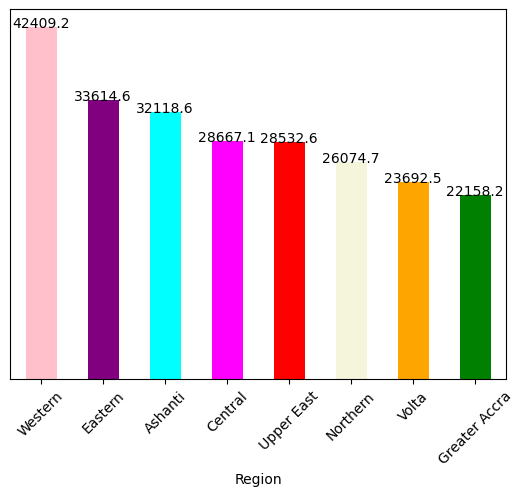

In [16]:
### compare the volume of rainfall in each region
bar_color=["pink","purple","cyan","magenta","red","beige","orange","green"]
data=agric_df.groupby("Region")["Rainfall_mm"].sum().sort_values(ascending=False)
ax_agric=data.plot(kind="bar",color=bar_color)
#ax_agric.xticks[rotation=45]
plt.xticks(rotation=45)
### add labels
for x,y in enumerate(data.values):
    plt.text(x,y,f"{y:.1f}", ha = "center")
plt.yticks([])
plt.show()

### Clustered Bar Chart

In [17]:
agric_df.dtypes

RecordID             int64
FarmID               int64
FarmName            object
Region              object
CropType            object
Year                 int64
Month                int64
Rainfall_mm        float64
Soil_pH            float64
Soil_Nitrogen      float64
Soil_Phosphorus    float64
Yield_Tonnes       float64
dtype: object

In [18]:
### clean the crop data set
crop_df.isna().sum()

CropID               0
FarmID               0
CropName             0
PlantingDate         0
HarvestDate          0
Yield_kg_per_ha    101
Region              76
dtype: int64

In [19]:
crop_df["Region"] = crop_df["Region"].fillna(crop_df["Region"].mode())

In [20]:
crop_df["Region"].fillna("Northern", inplace = True)

In [21]:
###crop_df["Yield_kg_per_ha"] = crop_df["Yield_kg_per_ha"].fillna(crop_df["Yield_kg_per_ha"].mean())

In [22]:
###crop_df["Region"].isna().sum()

In [23]:
crop_df["CropName"].nunique()

5

In [24]:
crop_df["Region"].nunique()

4

### Clustered bar chart

In [25]:
### Compare average yield for each crop in each region
### using the pivot table
avg_yield_reg=crop_df.pivot_table(values="Yield_kg_per_ha",index="CropName",columns="Region",aggfunc="mean")

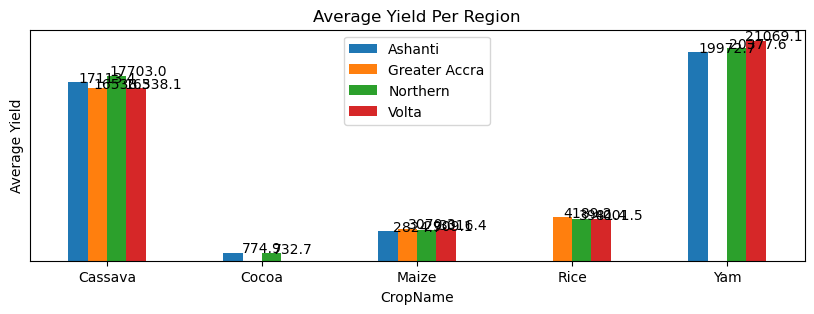

In [26]:
avg_yield_reg.plot(kind="bar",figsize=(10,3),label="Region")
plt.xticks(rotation=0)
plt.yticks([])
plt.ylabel("Average Yield")
plt.title("Average Yield Per Region")
plt.legend()
### Add data Labels
for i, value in enumerate(avg_yield_reg.values):
    for k, data_label in enumerate(value):
        plt.text(i + k*0.1, data_label, f"{data_label:.1f}",ha="center")
plt.show()

### pie chart

In [27]:
### The share of each region
reg_count=crop_df["Region"].value_counts()

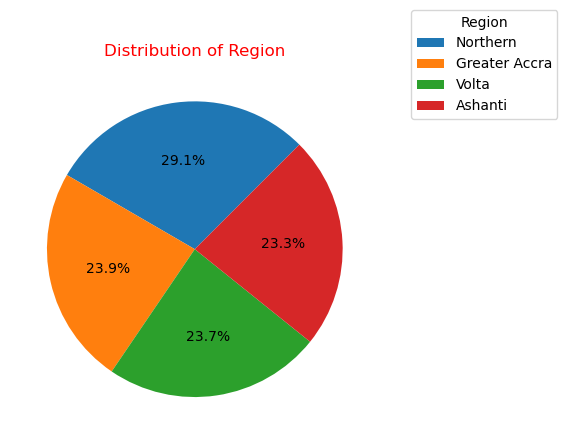

In [28]:
### ploting on the pie chart
reg_count.plot(kind = "pie", startangle = 45, autopct = "%1.1f%%",labels=None)
plt.legend(reg_count.index,title="Region",loc= "center right",bbox_to_anchor=(1.5,1))
plt.ylabel("")
plt.title("Distribution of Region",color="red")
plt.show()

### Scatter plot

In [29]:
agric_df.dtypes

RecordID             int64
FarmID               int64
FarmName            object
Region              object
CropType            object
Year                 int64
Month                int64
Rainfall_mm        float64
Soil_pH            float64
Soil_Nitrogen      float64
Soil_Phosphorus    float64
Yield_Tonnes       float64
dtype: object

Text(0.5, 1.0, 'Soil_pH and Rainfall_mm')

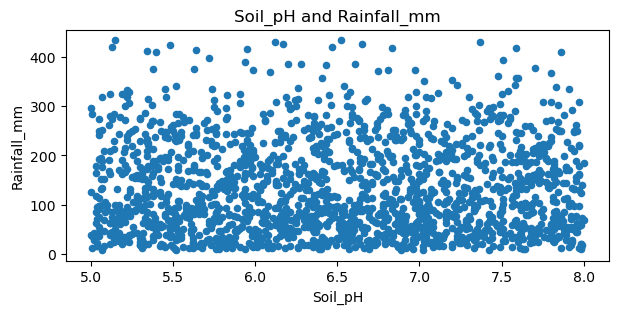

In [30]:
### check for the relationship between rainfall and soil_pH
### position of x and y doesnot matter
agric_df.plot(kind="scatter", y="Rainfall_mm",x="Soil_pH",figsize=(7,3))
plt.title("Soil_pH and Rainfall_mm")

### help(plt) 
- will give you all the documentations

### Box plot

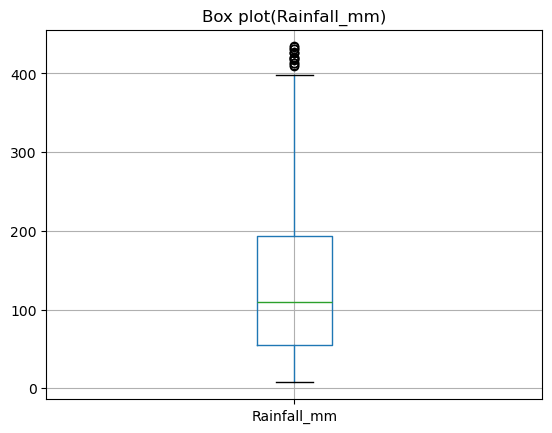

In [31]:

### checking for outliers
agric_df.boxplot(column="Rainfall_mm")
plt.title("Box plot(Rainfall_mm)")
plt.show()

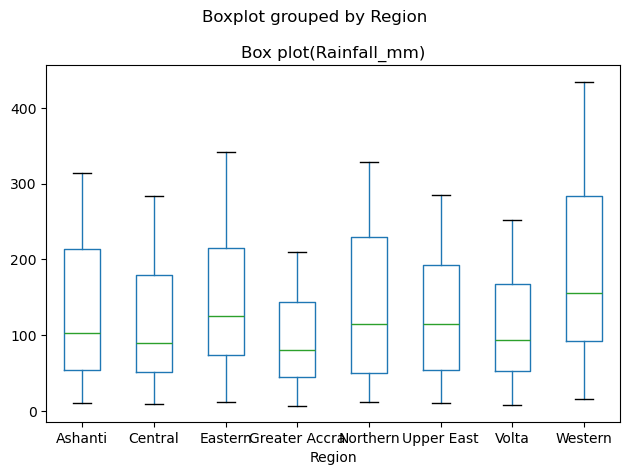

In [32]:
### checking for outliers by column
agric_df.boxplot(column="Rainfall_mm",by ="Region")
plt.title("Box plot(Rainfall_mm)")
plt.grid(False)
plt.tight_layout()
plt.show()

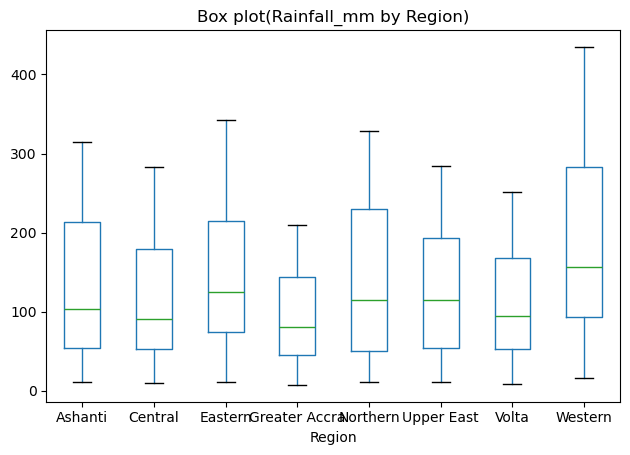

In [33]:
### checking for outliers on the rainfall column
### using a category
agric_df.boxplot(column = "Rainfall_mm", by = "Region")
plt.title("Box plot(Rainfall_mm by Region)")
plt.grid(False)
plt.suptitle("")
plt.tight_layout()
plt.show()

### Seaborn

### Scatter plot

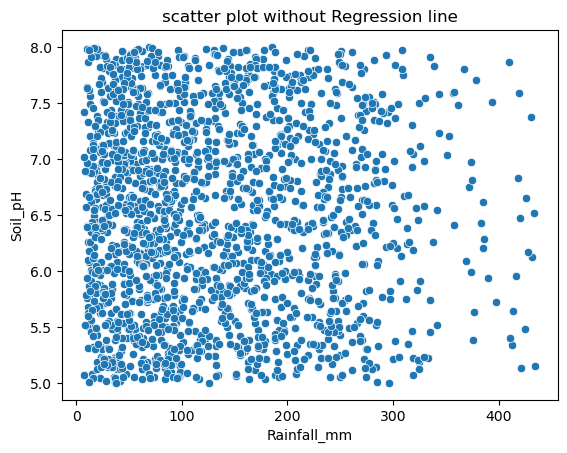

In [34]:
## relationship between rainfall and soil_pH
sns.scatterplot(data=agric_df, x="Rainfall_mm",y="Soil_pH")
plt.title("scatter plot without Regression line")
plt.show()

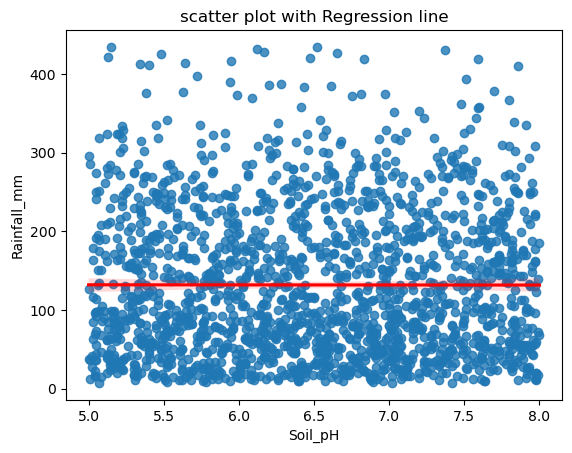

In [35]:
sns.regplot(data=agric_df, y="Rainfall_mm",x="Soil_pH",line_kws={"color":"red"})
plt.title("scatter plot with Regression line")
plt.show()

In [36]:
 ### checking for correlation co efficient
agric_df[["Rainfall_mm","Soil_pH"]].corr()

,Rainfall_mm,Soil_pH
Rainfall_mm,1.000000,-0.000984
Soil_pH,-0.000984,1.000000


In [37]:
### sshow correlation coffecient for all numeric columns
numeric=agric_df.select_dtypes(include="number")
numeric.corr()

,RecordID,FarmID,Year,Month,Rainfall_mm,Soil_pH,Soil_Nitrogen,Soil_Phosphorus,Yield_Tonnes
RecordID,1.000000,0.999861,0.022566,0.009257,0.030563,-0.019490,0.018149,-0.008016,-0.003558
FarmID,0.999861,1.000000,0.022768,0.009311,0.030566,-0.020210,0.018101,-0.007975,-0.003567
Year,0.022566,0.022768,1.000000,-0.018476,-0.018108,-0.038126,-0.035696,-0.013760,-0.012395
Month,0.009257,0.009311,-0.018476,1.000000,0.248018,-0.045688,-0.010828,-0.002423,-0.008719
Rainfall_mm,0.030563,0.030566,-0.018108,0.248018,1.000000,-0.000984,0.028509,-0.030333,-0.022633
Soil_pH,-0.019490,-0.020210,-0.038126,-0.045688,-0.000984,1.000000,-0.058661,0.028947,-0.015503
Soil_Nitrogen,0.018149,0.018101,-0.035696,-0.010828,0.028509,-0.058661,1.000000,-0.014571,0.120139
Soil_Phosphorus,-0.008016,-0.007975,-0.013760,-0.002423,-0.030333,0.028947,-0.014571,1.000000,0.001768
Yield_Tonnes,-0.003558,-0.003567,-0.012395,-0.008719,-0.022633,-0.015503,0.120139,0.001768,1.000000


### Heatmap

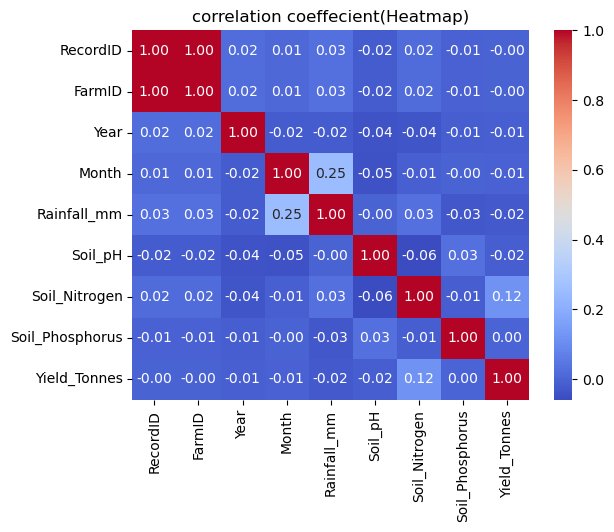

In [38]:
sns.heatmap(numeric.corr(),cmap="coolwarm",annot=True,fmt=".2f") ## coolwarm is the color -it can also be set 2,set 3
plt.title("correlation coeffecient(Heatmap)")
plt.show()

### Histogram

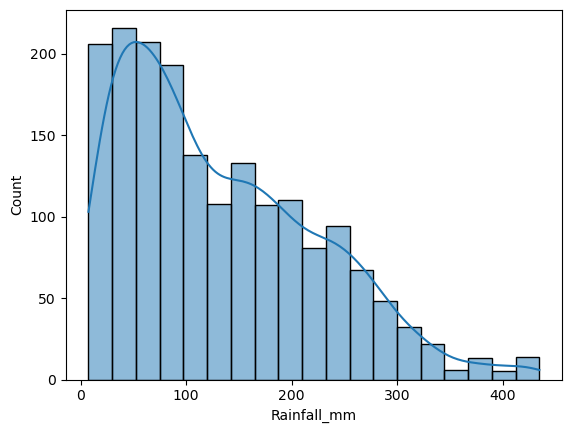

In [39]:
### check for the distribution of rainfall_mm values
sns.histplot(agric_df["Rainfall_mm"],kde=True) ### kde is the density line
plt.show()

In [40]:
crop_df.to_csv("clean_crop.csv",index=False) 

### Pairplot

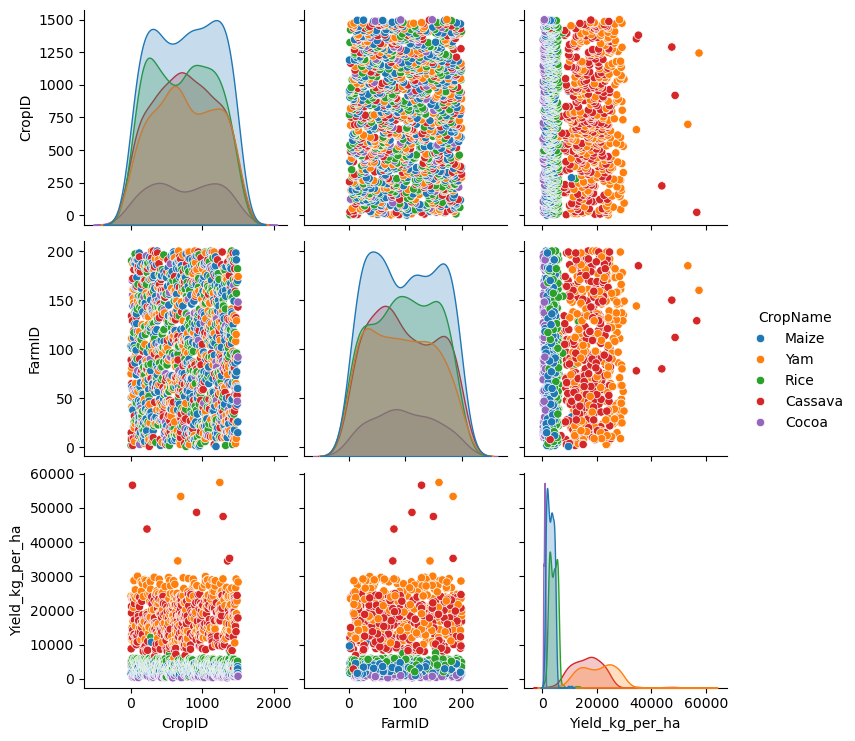

In [41]:
sns.pairplot(crop_df,hue="CropName")###,kind="reg") this used for showing the regression line
plt.show()